=== 启动差值分析 (CE Analysis) ===
Case A: Level 1, Shift 2
Case B: Level 2, Shift 2
差值范围: [-0.6746, 0.3206]
平均差异: -0.0581 bits


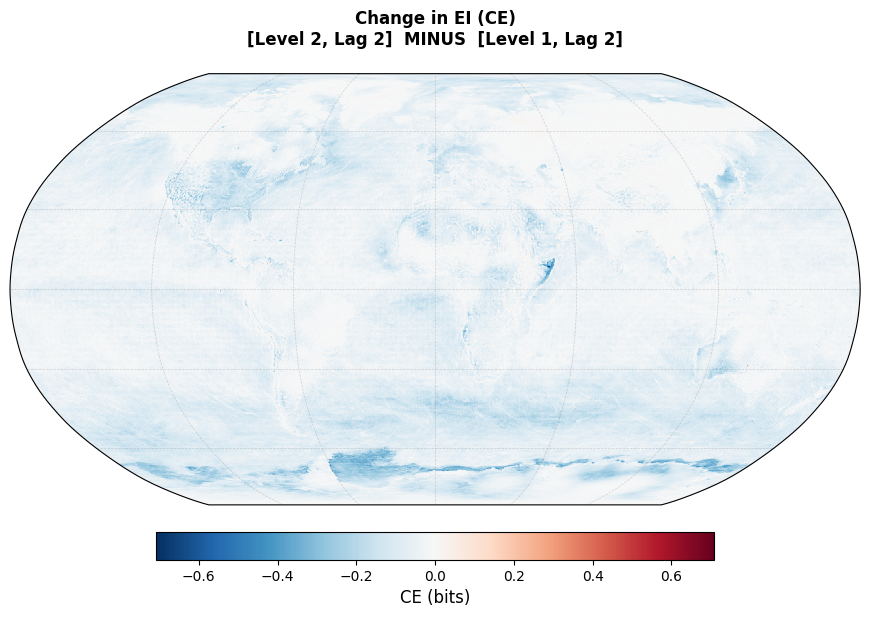

差值图已保存: figure_CE_analysis/diff_L1S2_vs_L2S2.png


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import config as cfg

# ————————————————————————
# 1. 配置对比参数
# ————————————————————————
# 比较对象 A (减数)
CASE_A = {'level': 1, 'shift': 2} 

# 比较对象 B (被减数)
# 计算公式: Diff = CASE_B - CASE_A
# 意义: B 相对于 A 的变化
CASE_B = {'level': 2, 'shift': 2} 

# 配色设置
# True: 使用您的自定义马卡龙色带 (我会将其构建为渐变)
# False: 使用系统标准的 'RdBu_r' (红-白-蓝，适合展示正负差值)
USE_CUSTOM_COLOR = False
MATRIX_PATH='matrix_te_avg_pairwise_1'
# 输出目录
OUTPUT_DIR = "figure_CE_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def get_file_path(level, shift):
    """根据参数构建文件路径"""
    # 假设文件名格式为: te_map_level_{}_shift_{}.npy (来自 main.py)
    # 或者: hourly_te_level{}_hour{}.npy (来自 main_hourly.py)
    # 根据您想对比的是 "Lag分析" 还是 "小时分析" 修改这里
    # 这里默认使用 main.py 的 Lag 分析结果
    filename = f"te_map_level_{level}_shift_{shift}.npy"
    return os.path.join(MATRIX_PATH, filename)


def plot_difference():
    print(f"=== 启动差值分析 (CE Analysis) ===")
    print(f"Case A: Level {CASE_A['level']}, Shift {CASE_A['shift']}")
    print(f"Case B: Level {CASE_B['level']}, Shift {CASE_B['shift']}")
    
    # 1. 读取数据
    path_a = get_file_path(CASE_A['level'], CASE_A['shift'])
    path_b = get_file_path(CASE_B['level'], CASE_B['shift'])
    
    if not os.path.exists(path_a) or not os.path.exists(path_b):
        print("错误: 找不到指定参数的数据文件。请检查 config.MATRIX_PATH 和文件名格式。")
        return

    try:
        map_a = np.load(path_a)
        map_b = np.load(path_b)
        
        # 2. 计算差值 (CE)
        # Diff > 0: B 比 A 强 (红色)
        # Diff < 0: B 比 A 弱 (蓝色)
        diff_map = map_b - map_a
        
        # 统计信息
        max_diff = np.nanmax(diff_map)
        min_diff = np.nanmin(diff_map)
        avg_diff = np.nanmean(diff_map)
        
        print(f"差值范围: [{min_diff:.4f}, {max_diff:.4f}]")
        print(f"平均差异: {avg_diff:.4f} bits")

        # 3. 准备绘图
        # 模拟经纬度 (实际应从 data_utils 加载)
        nlat, nlon = diff_map.shape
        lats = np.linspace(90, -90, nlat)
        lons = np.linspace(0, 360, nlon)
        
        fig = plt.figure(figsize=(12, 7))
        proj = ccrs.Robinson(central_longitude=0)
        ax = fig.add_subplot(1, 1, 1, projection=proj)
        
        # cmap = plt.cm.RdBu_r 
            
        # 5. 设置色标范围 (关键！)
        # 为了让 0 值对应色带的正中心（白色），我们需要构建对称的 vmin/vmax
        # 找出绝对值最大的偏差
        abs_max = max(abs(min_diff), abs(max_diff))
        # 稍微放大一点点边界
        limit = abs_max * 1.05
        
        # 6. 绘制
        im = ax.pcolormesh(lons, lats, diff_map,
                           transform=ccrs.PlateCarree(),
                           cmap='RdBu_r',
                           vmin=-limit, # 负极限
                           vmax=limit)  # 正极限
        
        # 7. 美化
        # ax.coastlines(resolution='110m', linewidth=0.8, color='black')
        # ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='gray')
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
        
        # 色条
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05)
        cbar.set_label('CE (bits)', fontsize=12)
        
        # 标题
        title_str = (f"Change in EI (CE)\n"
                     f"[Level {CASE_B['level']}, Lag {CASE_B['shift']}]  MINUS  [Level {CASE_A['level']}, Lag {CASE_A['shift']}]\n"
                     )
        plt.title(title_str, fontsize=12, fontweight='bold')
        
        # 保存
        file_name = f"diff_L{CASE_A['level']}S{CASE_A['shift']}_vs_L{CASE_B['level']}S{CASE_B['shift']}.png"
        save_path = os.path.join(OUTPUT_DIR, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"差值图已保存: {save_path}")
        
    except Exception as e:
        print(f"计算或绘图出错: {e}")

if __name__ == "__main__":
    plot_difference()

=== 启动差值分析 (CE Analysis) ===
Case A: Level 2, Shift 1
Case B: Level 1, Shift 1
应用分界点: [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15]
差值统计: Min=-0.3050, Max=0.2717, Mean=0.0028


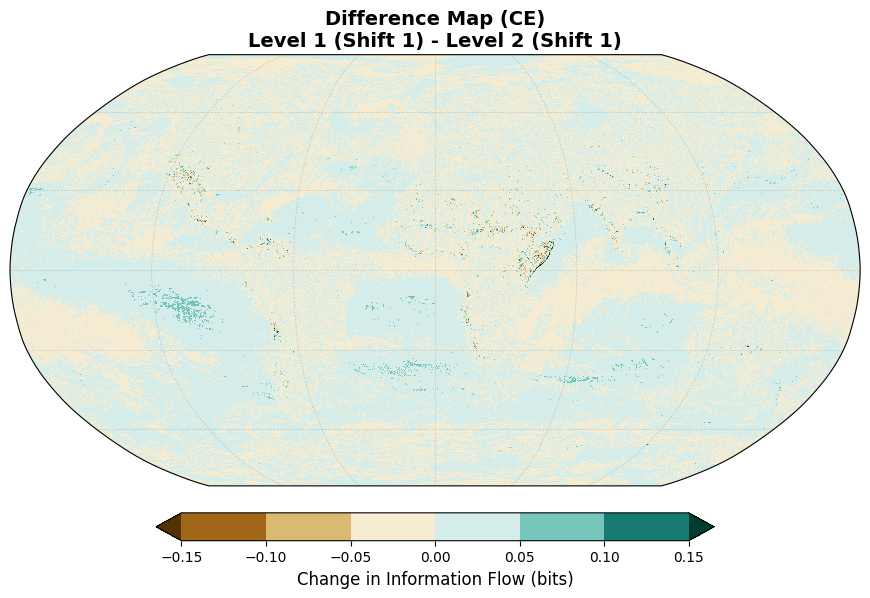

差值图已保存: figure_CE_analysis/diff_L2S1_vs_L1S1_discrete.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import config as cfg

# ——————————————————————————————————————————————
# 1. 配置对比参数
# ——————————————————————————————————————————————
# 比较对象 A (减数)
CASE_A = {'level': 2, 'shift': 1} 

# 比较对象 B (被减数)
# Diff = B - A
CASE_B = {'level': 1, 'shift': 1} 

MATRIX_PATH='matrix_te_avg_pairwise_1'
# 输出目录
OUTPUT_DIR = "figure_CE_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ——————————————————————————————————————————————
# 2. 【核心修改】自定义分界点 (Levels)
# ——————————————————————————————————————————————
# 您可以在这里修改为您想要的任意分界点
# 建议：保持关于 0 对称，以便红蓝颜色对齐

# # 方案 A: 小范围精细对比
CUSTOM_LEVELS = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15]

# 方案 B: 大范围对比 (如果差值很大，可以取消注释使用这一组)
# CUSTOM_LEVELS = [-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3]

# 方案 C: 更加细密的刻度
# CUSTOM_LEVELS = np.arange(-0.2, 0.21, 0.02) # 生成 -0.2 到 0.2，步长 0.02

# 色带选择
# 'RdBu_r': 红-白-蓝 (最常用，红色为正，蓝色为负)
# 'PuOr': 紫-白-橙
# 'PiYG': 粉-白-绿
#BrBG 棕-百-绿
COLORMAP_NAME = 'BrBG' 

def get_file_path(level, shift):
    """根据参数构建文件路径"""
    filename = f"te_map_level_{level}_shift_{shift}.npy"
    return os.path.join(MATRIX_PATH, filename)

def get_discrete_cmap_norm(levels, cmap_name):
    """
    根据分界点自动生成离散色带和归一化对象
    """
    # 1. 获取基础连续色带
    base_cmap = plt.get_cmap(cmap_name)
    
    # 2. 计算需要的颜色数量
    # 基础区间数 = len(levels) - 1
    # 加上两端延伸 (extend='both')，我们需要从连续色带中取样出更多的颜色
    # 逻辑：我们将连续色带分成 N 份，每个区间取一个颜色
    n_bins = len(levels) - 1+2
    
    # 使用 get_cmap(name, lut) 可以直接获取离散采样
    # 注意：为了让 0 对应中间的白色，RdBu_r 这类发散色带最好采样奇数个或者是对称的
    discrete_cmap = plt.get_cmap(cmap_name, n_bins)
    
    # 3. 创建 BoundaryNorm
    # extend='both' 表示超出 levels 范围的值也将被绘制（使用色带两极的颜色）
    norm = mcolors.BoundaryNorm(levels, ncolors=discrete_cmap.N, extend='both')
    
    return discrete_cmap, norm

def plot_difference():
    print(f"=== 启动差值分析 (CE Analysis) ===")
    print(f"Case A: Level {CASE_A['level']}, Shift {CASE_A['shift']}")
    print(f"Case B: Level {CASE_B['level']}, Shift {CASE_B['shift']}")
    print(f"应用分界点: {CUSTOM_LEVELS}")
    
    path_a = get_file_path(CASE_A['level'], CASE_A['shift'])
    path_b = get_file_path(CASE_B['level'], CASE_B['shift'])
    
    if not os.path.exists(path_a) or not os.path.exists(path_b):
        print("错误: 找不到指定参数的数据文件。")
        return

    try:
        map_a = np.load(path_a)
        map_b = np.load(path_b)
        
        # 计算差值
        diff_map = map_b - map_a
        
        # 统计信息
        print(f"差值统计: Min={np.nanmin(diff_map):.4f}, Max={np.nanmax(diff_map):.4f}, Mean={np.nanmean(diff_map):.4f}")

        # 模拟经纬度 (实际建议从 load_nc_data 获取一次以防万一)
        nlat, nlon = diff_map.shape
        lats = np.linspace(90, -90, nlat)
        lons = np.linspace(0, 360, nlon)
        
        # 创建画布
        fig = plt.figure(figsize=(12, 7))
        proj = ccrs.Robinson(central_longitude=0)
        ax = fig.add_subplot(1, 1, 1, projection=proj)
        
        # ————————————————————————————————————
        # 获取自定义离散色带
        # ————————————————————————————————————
        cmap, norm = get_discrete_cmap_norm(CUSTOM_LEVELS, COLORMAP_NAME)
        
        # 绘制
        im = ax.pcolormesh(lons, lats, diff_map,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap,
                           norm=norm)
        
        # 美化
        # ax.coastlines(resolution='110m', linewidth=0.8, color='black')
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
        
        # 色条 (自动适配离散区间)
        # spacing='uniform' 让每个色块等宽，即使数值跨度不同
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, 
                            spacing='uniform') 
        cbar.set_label('Change in Information Flow (bits)', fontsize=12)
        
        # 标题
        title_str = (f"Difference Map (CE)\n"
                     f"Level {CASE_B['level']} (Shift {CASE_B['shift']}) - Level {CASE_A['level']} (Shift {CASE_A['shift']})")
        plt.title(title_str, fontsize=14, fontweight='bold')
        
        # 保存
        file_name = f"diff_L{CASE_A['level']}S{CASE_A['shift']}_vs_L{CASE_B['level']}S{CASE_B['shift']}_discrete.png"
        save_path = os.path.join(OUTPUT_DIR, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"差值图已保存: {save_path}")
        
    except Exception as e:
        print(f"计算或绘图出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    plot_difference()

=== 启动差值分析 (CE Analysis) ===
对比: L1S1 (Base) vs L1S2 (Target)
正在绘制增强版分布对比图 (Distribution Comparison with CE)...


/tmp/ipykernel_1597202/2890783008.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_all, x="Category", y="Value", ax=axes[1],


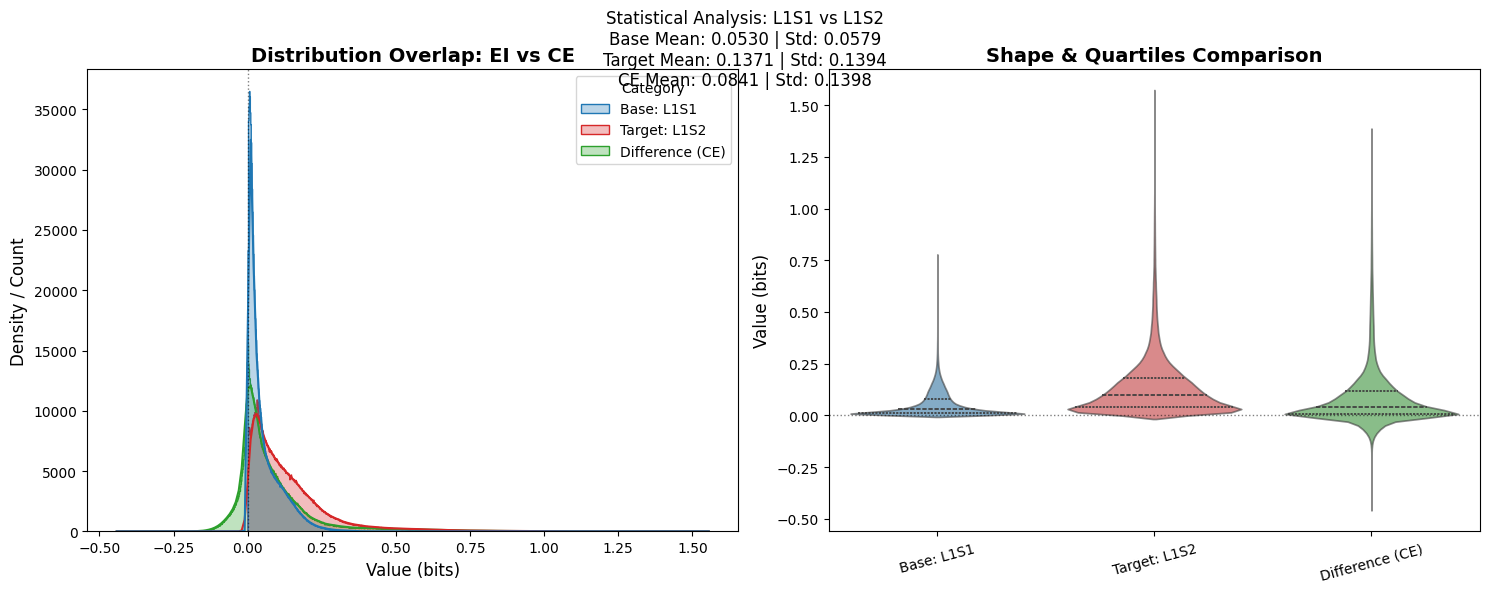

正在绘制空间差值图...


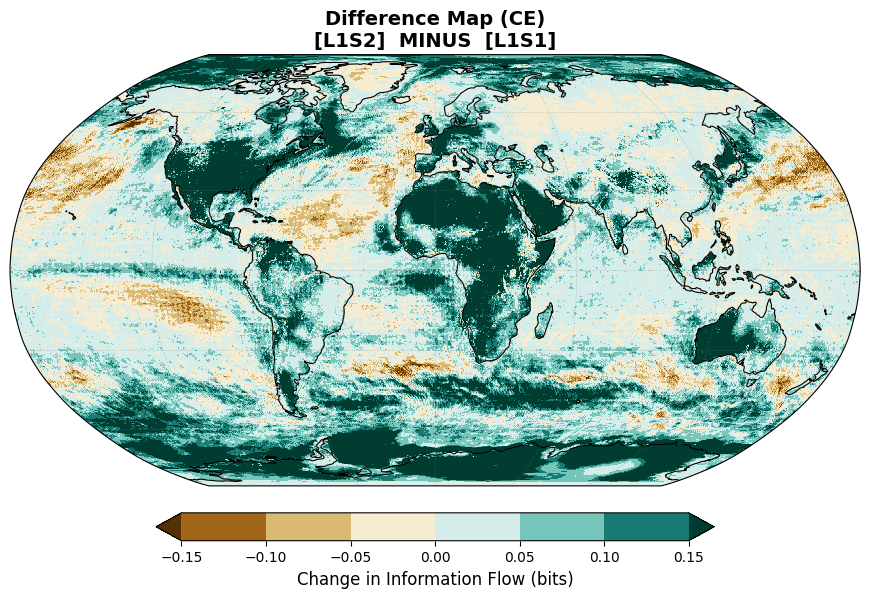

差值图已保存: figure_CE_analysis/diff_L1S1_vs_L1S2_discrete.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import config as cfg
import pandas as pd

# ——————————————————————————————————————————————
# 1. 配置对比参数
# ——————————————————————————————————————————————
# 比较对象 A (Baseline / 减数)
CASE_A = {'level': 1, 'shift': 1} 

# 比较对象 B (Comparison / 被减数)
# Diff = B - A
CASE_B = {'level': 1, 'shift': 2} 

MATRIX_PATH='matrix_te_avg_pairwise_1'
# 输出目录
OUTPUT_DIR = "figure_CE_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ——————————————————————————————————————————————
# 2. 自定义分界点 (差值图用)
# ——————————————————————————————————————————————
# # 方案 A: 小范围精细对比
CUSTOM_LEVELS = [-0.15, -0.10, -0.05, 0, 0.05, 0.10, 0.15]

# 方案 B: 大范围对比 (如果差值很大，可以取消注释使用这一组)
# CUSTOM_LEVELS = [-0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3]

# 方案 C: 更加细密的刻度
# CUSTOM_LEVELS = np.arange(-0.2, 0.21, 0.02) # 生成 -0.2 到 0.2，步长 0.02

# 色带选择
# 'RdBu_r': 红-白-蓝 (最常用，红色为正，蓝色为负)
# 'PuOr': 紫-白-橙
# 'PiYG': 粉-白-绿
#BrBG 棕-百-绿
COLORMAP_NAME = 'BrBG' 


def get_file_path(level, shift):
    """根据参数构建文件路径"""
    filename = f"te_map_level_{level}_shift_{shift}.npy"
    return os.path.join(MATRIX_PATH, filename)

def get_discrete_cmap_norm(levels, cmap_name):
    """根据分界点自动生成离散色带和归一化对象"""
    base_cmap = plt.get_cmap(cmap_name)
    n_basic_bins = len(levels) - 1
    n_total_colors = n_basic_bins + 2 
    discrete_cmap = plt.get_cmap(cmap_name, n_total_colors)
    norm = mcolors.BoundaryNorm(levels, ncolors=discrete_cmap.N, extend='both')
    return discrete_cmap, norm

# ——————————————————————————————————————————————
# 3. [增强版] 分布对比绘图函数 (含 CE)
# ——————————————————————————————————————————————
def plot_distribution_comparison(map_a, map_b, diff_map, label_a, label_b):
    print("正在绘制增强版分布对比图 (Distribution Comparison with CE)...")
    
    # 1. 数据准备 (展平并去 NaN)
    val_a = map_a.flatten(); val_a = val_a[~np.isnan(val_a)]
    val_b = map_b.flatten(); val_b = val_b[~np.isnan(val_b)]
    val_diff = diff_map.flatten(); val_diff = val_diff[~np.isnan(val_diff)]
    
    # 构造 DataFrame
    # 为每组数据指定清晰的 Label
    df_a = pd.DataFrame({'Value': val_a, 'Category': f"Base: {label_a}"})
    df_b = pd.DataFrame({'Value': val_b, 'Category': f"Target: {label_b}"})
    df_ce = pd.DataFrame({'Value': val_diff, 'Category': "Difference (CE)"})
    
    df_all = pd.concat([df_a, df_b, df_ce], ignore_index=True)
    
    # 2. 设置画布
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 定义配色 (蓝、红、绿)
    # 蓝色=Base, 红色=Target, 绿色=Difference
    palette = ["#1f77b4", "#d62728", "#2ca02c"]
    
    # --- 子图 1: 直方图 + KDE ---
    sns.histplot(data=df_all, x="Value", hue="Category", kde=True, 
                 element="step", common_norm=False, ax=axes[0], 
                 palette=palette, alpha=0.3, linewidth=1)
    
    axes[0].set_title("Distribution Overlap: EI vs CE", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Value (bits)", fontsize=12)
    axes[0].set_ylabel("Density / Count", fontsize=12)
    # 添加网格方便看 0 点
    axes[0].axvline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    # --- 子图 2: 小提琴图 (Violin) ---
    # 使用 split=False, inner='quartile'
    sns.violinplot(data=df_all, x="Category", y="Value", ax=axes[1], 
                   palette=palette, alpha=0.6, inner="quartile")
    
    axes[1].set_title("Shape & Quartiles Comparison", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("", fontsize=12)
    axes[1].set_ylabel("Value (bits)", fontsize=12)
    axes[1].axhline(0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    # 旋转 x 轴标签防止重叠
    axes[1].tick_params(axis='x', rotation=15)
    
    # 添加统计摘要
    stats_str = (
        f"Base Mean: {np.mean(val_a):.4f} | Std: {np.std(val_a):.4f}\n"
        f"Target Mean: {np.mean(val_b):.4f} | Std: {np.std(val_b):.4f}\n"
        f"CE Mean: {np.mean(val_diff):.4f} | Std: {np.std(val_diff):.4f}"
    )
    fig.suptitle(f"Statistical Analysis: {label_a} vs {label_b}\n{stats_str}", 
                 fontsize=12, y=0.98)
    
    plt.tight_layout()
    # 留出顶部给 suptitle
    plt.subplots_adjust(top=0.88)
    
    # 保存
    save_name = f"dist_L{CASE_A['level']}S{CASE_A['shift']}_vs_L{CASE_B['level']}S{CASE_B['shift']}_with_CE.png"
    save_path = os.path.join(OUTPUT_DIR, save_name)
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    # print(f"分布对比图已保存: {save_path}")

def plot_difference():
    print(f"=== 启动差值分析 (CE Analysis) ===")
    label_a = f"L{CASE_A['level']}S{CASE_A['shift']}"
    label_b = f"L{CASE_B['level']}S{CASE_B['shift']}"
    print(f"对比: {label_a} (Base) vs {label_b} (Target)")
    
    path_a = get_file_path(CASE_A['level'], CASE_A['shift'])
    path_b = get_file_path(CASE_B['level'], CASE_B['shift'])
    
    if not os.path.exists(path_a) or not os.path.exists(path_b):
        print("错误: 找不到指定参数的数据文件。")
        return

    try:
        map_a = np.load(path_a)
        map_b = np.load(path_b)
        
        # 1. 先计算差值
        diff_map = map_b - map_a
        
        # 2. 绘制分布图 (含 CE)
        plot_distribution_comparison(map_a, map_b, diff_map, label_a, label_b)
        
        # 3. 绘制空间差值图 (原有逻辑)
        print("正在绘制空间差值图...")
        
        # 模拟经纬度
        nlat, nlon = diff_map.shape
        lats = np.linspace(90, -90, nlat)
        lons = np.linspace(0, 360, nlon)
        
        fig = plt.figure(figsize=(12, 7))
        proj = ccrs.Robinson(central_longitude=0)
        ax = fig.add_subplot(1, 1, 1, projection=proj)
        
        cmap, norm = get_discrete_cmap_norm(CUSTOM_LEVELS, COLORMAP_NAME)
        
        im = ax.pcolormesh(lons, lats, diff_map,
                           transform=ccrs.PlateCarree(),
                           cmap=cmap,
                           norm=norm)
        
        ax.coastlines(resolution='110m', linewidth=0.8, color='black')
        ax.gridlines(draw_labels=False, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')
        
        cbar = plt.colorbar(im, ax=ax, orientation='horizontal', shrink=0.6, pad=0.05, 
                            spacing='uniform') 
        cbar.set_label('Change in Information Flow (bits)', fontsize=12)
        
        title_str = (f"Difference Map (CE)\n"
                     f"[{label_b}]  MINUS  [{label_a}]")
        plt.title(title_str, fontsize=14, fontweight='bold')
        
        file_name = f"diff_{label_a}_vs_{label_b}_discrete.png"
        save_path = os.path.join(OUTPUT_DIR, file_name)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
        
        print(f"差值图已保存: {save_path}")
        
    except Exception as e:
        print(f"计算或绘图出错: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    plot_difference()

正在扫描并汇总数据...
汇总完成: 找到 134 个文件, 缺失 266 个
热力图已保存: causal/paper_te/figure_te_avg_pairwise/global_ei_summary_heatmap.png


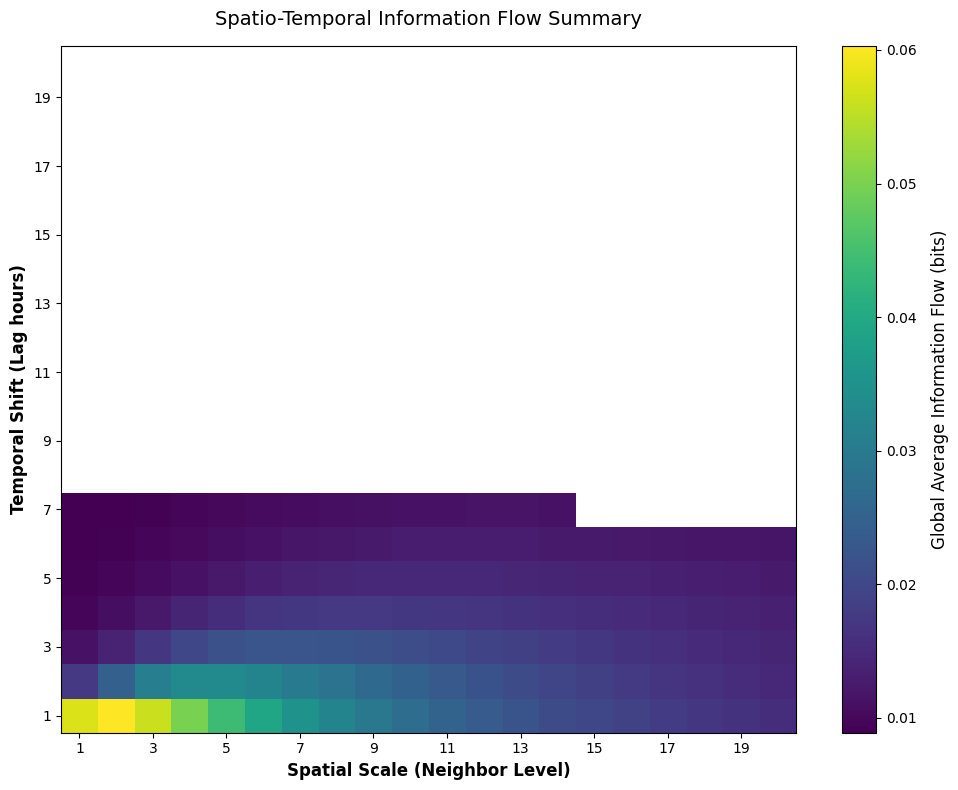

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import config as cfg

path='matrix_te_avg_pairwise'

def load_and_summarize():
    """
    读取所有单独的 .npy 文件，重新构建汇总矩阵
    """
    print("正在扫描并汇总数据...")
    
    # 初始化汇总矩阵 (行: Lag, 列: Level)
    # 大小为 (LAG_MAX + 1, MAX_LEVEL + 1)
    summary_matrix = np.full((cfg.LAG_MAX + 1, cfg.MAX_LEVEL + 1), np.nan)
    
    found_count = 0
    missing_count = 0
    
    # 双重循环遍历所有组合
    for lag in range(1, cfg.LAG_MAX + 1):
        for level in range(1, cfg.MAX_LEVEL + 1):
            # 构建文件名 (需与 main.py 中的命名一致)
            # 格式: te_map_level_{level}_shift_{lag}.npy
            file_name = f"te_map_level_{level}_shift_{lag}.npy"
            # file_path = os.path.join(cfg.MATRIX_PATH, file_name)
            # file_name = f"mi_map_level_{level}_lag_{lag}.npy"

            file_path = os.path.join(path, file_name)
            if os.path.exists(file_path):
                try:
                    # 读取矩阵
                    data = np.load(file_path)
                    # 计算全局均值 (忽略 NaN)
                    mean_val = np.nanmean(data)
                    summary_matrix[lag, level] = mean_val
                    found_count += 1
                except Exception as e:
                    print(f"读取错误 {file_name}: {e}")
            else:
                missing_count += 1
                # print(f"文件缺失: {file_name}")

    print(f"汇总完成: 找到 {found_count} 个文件, 缺失 {missing_count} 个")
    return summary_matrix

def plot_heatmap(matrix):
    """
    绘制 Lag vs Level 的热力图
    """
    # 裁剪矩阵：去掉第0行和第0列（因为 lag 和 level 通常从 1 开始）
    # plot_data 的形状将是 (LAG_MAX, MAX_LEVEL)
    plot_data = matrix[1:, 1:]
    
    # 准备坐标轴标签
    # X轴: Level (1 到 MAX_LEVEL)
    levels = np.arange(1, cfg.MAX_LEVEL + 1)
    # Y轴: Lag (1 到 LAG_MAX)
    lags = np.arange(1, cfg.LAG_MAX + 1)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 使用 imshow 绘制热力图
    # origin='lower' 让 lag=1 在底部，lag=max 在顶部 (符合直觉)
    # aspect='auto' 自动调整方块形状填充画布
    im = ax.imshow(plot_data, 
                   origin='lower', 
                   cmap='viridis',  # 或者 'plasma', 'magma', 'turbo'
                   aspect='auto',
                   extent=[0.5, cfg.MAX_LEVEL + 0.5, 0.5, cfg.LAG_MAX + 0.5])
    
    # 添加色条
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Global Average Information Flow (bits)', fontsize=12, labelpad=10)
    
    # 设置坐标轴标签
    ax.set_xlabel('Spatial Scale (Neighbor Level)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Temporal Shift (Lag hours)', fontsize=12, fontweight='bold')
    
    # 设置刻度
    # 如果 Level 很多，可以每隔几个显示一个
    if cfg.MAX_LEVEL > 15:
        ax.set_xticks(np.arange(1, cfg.MAX_LEVEL + 1, 2))
    else:
        ax.set_xticks(np.arange(1, cfg.MAX_LEVEL + 1))
        
    if cfg.LAG_MAX > 15:
        ax.set_yticks(np.arange(1, cfg.LAG_MAX + 1, 2))
    else:
        ax.set_yticks(np.arange(1, cfg.LAG_MAX + 1))
        
    # 添加数值标注 (如果在网格不太密集的情况下)
    # 如果格子太多 (比如 20x20)，显示数字会很乱，建议注释掉
    if cfg.MAX_LEVEL <= 10 and cfg.LAG_MAX <= 10:
        for i in range(plot_data.shape[0]):     # Lag (rows)
            for j in range(plot_data.shape[1]): # Level (cols)
                val = plot_data[i, j]
                if not np.isnan(val):
                    ax.text(j + 1, i + 1, f"{val:.2f}", 
                            ha="center", va="center", color="w", fontsize=8)

    # 标题
    ax.set_title("Spatio-Temporal Information Flow Summary", fontsize=14, pad=15)
    
    # 保存
    save_path = os.path.join(cfg.FIGURE_PATH, "global_ei_summary_heatmap.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"热力图已保存: {save_path}")
    
    # 同时保存汇总矩阵数据
    np.save(os.path.join(path, "global_ei_summary_matrix.npy"), matrix)

if __name__ == "__main__":
    # 1. 加载/构建矩阵
    summary = load_and_summarize()
    
    # 2. 绘图
    plot_heatmap(summary)

[[       nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan        nan        nan
         nan        nan        nan        nan        nan        nan
         nan        nan        nan]
 [       nan 0.05286327 0.05013921 0.04586481 0.04110657 0.03694194
  0.03370226 0.0310718  0.02895433 0.02701445 0.02544724 0.02400325
  0.02270877 0.02164239 0.02068479 0.01980432 0.01907566 0.01839717
  0.01778063 0.01720281 0.01665576]
 [       nan 0.14063988 0.08085084 0.05874426 0.04891399 0.04336741
  0.03957954 0.03679225 0.03446653 0.03244825 0.03064777 0.02898503
  0.02750799 0.02622573 0.02502999 0.02395574 0.02303241 0.02217016
  0.02137709 0.02063255 0.01997253]
 [       nan 0.17657515 0.12596115 0.09507698 0.0770427  0.06605054
  0.05877536 0.05375885 0.04992118 0.04699414 0.04451144 0.04230966
  0.04041918 0.03876432 0.03718701 0.03576104 0.03449533 0.0333252
  0.0322601  0.03127189 0.03038729]
 [       nan 0.17155847 0.13859818 0.1129

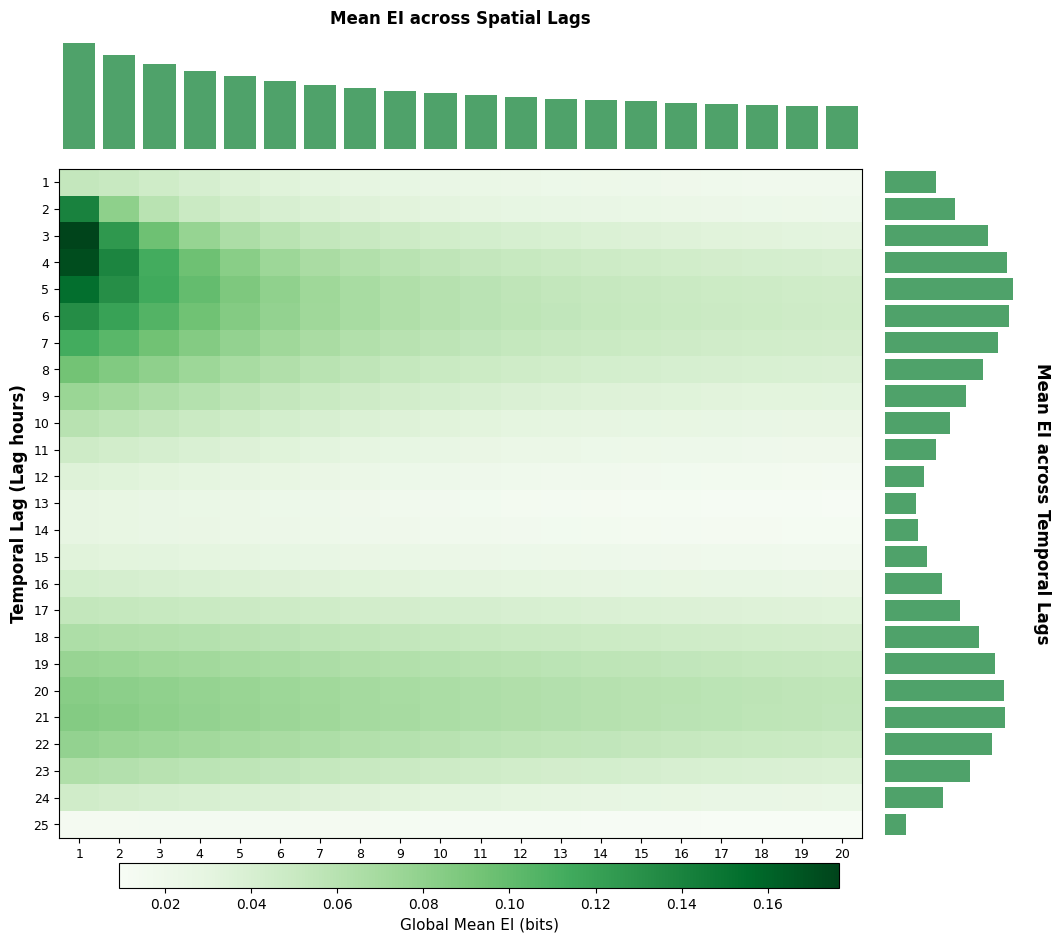

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import config as cfg

def plot_complex_heatmap():
    # 1. 加载汇总矩阵
    # 假设 matrix 形状为 (LAG_MAX+1, MAX_LEVEL+1)
    # path="matrix_te_avg_pairwise"
    # # matrix_path = os.path.join(cfg.MATRIX_PATH, "global_ei_summary_matrix.npy")
    # matrix_path = os.path.join(path, "global_ei_summary_matrix.npy")
    path="fast_heatmap_result_1000"
    # path="fast_heatmap_result_73"
    matrix_path = os.path.join(path, "fast_global_ei_matrix.npy")
    if not os.path.exists(matrix_path):
        print(f"错误: 找不到文件 {matrix_path}")
        return

    full_matrix = np.load(matrix_path)
    print(full_matrix)
    # 裁剪掉索引0的空数据，只取有效部分 (1..LAG_MAX, 1..MAX_LEVEL)
    # data_matrix[i, j] 对应 lag=i+1, level=j+1
    data_matrix = full_matrix[1:, 1:]
    
    n_lags, n_levels = data_matrix.shape
    
    # 2. 计算边缘均值 (Marginal Means)
    # 上方柱状图：对每一列求均值 -> 不同 Level 的平均表现
    # 注意：使用 nanmean 忽略可能的 NaN
    level_means = np.nanmean(data_matrix, axis=0) 
    
    # 右侧条形图：对每一行求均值 -> 不同 Lag 的平均表现
    lag_means = np.nanmean(data_matrix, axis=1)

    # 3. 设置画布和网格布局
    fig = plt.figure(figsize=(12, 10))
    
    # GridSpec: 2行2列
    # width_ratios: 热力图宽 : 右侧图宽 = 6 : 1
    # height_ratios: 上方图高 : 热力图高 = 1 : 6
    gs = gridspec.GridSpec(2, 2, width_ratios=[6, 1], height_ratios=[1, 6], 
                           wspace=0.05, hspace=0.05)

    # ——————————————————————————————————————————————
    # 子图 1: 上方柱状图 (Marginal Level EI)
    # ——————————————————————————————————————————————
    ax_top = plt.subplot(gs[0, 0])
    x_pos = np.arange(n_levels)
    
    # 绘制柱状图 (深绿色)
    # 也可以根据值的大小变色
    ax_top.bar(x_pos, level_means, color='#238B45', width=0.8, alpha=0.8)
    
    # 美化
    ax_top.set_xlim(-0.5, n_levels - 0.5)
    ax_top.axis('off') # 关闭坐标轴
    
    # 在柱子上显示数值 (可选)
    # max_val = np.nanmax(level_means)
    # for i, v in enumerate(level_means):
    #     ax_top.text(i, v + max_val*0.05, f"{v:.2f}", ha='center', va='bottom', fontsize=7, rotation=90)
        
    ax_top.set_title("Mean EI across Spatial Lags", fontsize=12, pad=10, fontweight='bold')

    # ——————————————————————————————————————————————
    # 子图 2: 右侧条形图 (Marginal Lag EI)
    # ——————————————————————————————————————————————
    ax_right = plt.subplot(gs[1, 1])
    y_pos = np.arange(n_lags)
    
    # 绘制水平条形图 (注意 y 轴翻转逻辑在后面)
    ax_right.barh(y_pos, lag_means, color='#238B45', height=0.8, alpha=0.8)
    
    # 美化
    # 关键：翻转 Y 轴，使 lag=1 在顶部，与 heatmap 对齐
    ax_right.set_ylim(n_lags - 0.5, -0.5) 
    ax_right.axis('off')
    
    # 在条形旁添加右侧文字说明
    ax_right.text(1.1, 0.5, "Mean EI across Temporal Lags", 
                  rotation=270, va='center', ha='left', transform=ax_right.transAxes, fontsize=12, fontweight='bold')

    # ——————————————————————————————————————————————
    # 子图 3: 中间热力图 (Main Heatmap)
    # ——————————————————————————————————————————————
    ax_main = plt.subplot(gs[1, 0])
    
    # 绘制热力图
    # cmap 建议用 'viridis' 或 'turbo' (如果想要高对比度)
    im = ax_main.imshow(data_matrix, cmap='Greens', aspect='auto', interpolation='nearest')
    
    # 设置刻度标签
    # X轴: Level (1, 2, ..., MAX_LEVEL)
    ax_main.set_xticks(np.arange(n_levels))
    ax_main.set_xticklabels(np.arange(1, n_levels + 1), fontsize=9)
    
    # Y轴: Lag (1, 2, ..., LAG_MAX)
    ax_main.set_yticks(np.arange(n_lags))
    ax_main.set_yticklabels(np.arange(1, n_lags + 1), fontsize=9)
    
    # 坐标轴标签
    ax_main.set_xlabel("Spatial Lag (Neighbor Level)", fontsize=12, fontweight='bold')
    ax_main.set_ylabel("Temporal Lag (Lag hours)", fontsize=12, fontweight='bold')
    
    # 如果网格不过密，显示数值
    if n_levels <= 15 and n_lags <= 25:
        for i in range(n_lags):
            for j in range(n_levels):
                val = data_matrix[i, j]
                if not np.isnan(val):
                    # 根据背景深浅自动调整字体颜色
                    text_color = "black" if val > np.nanmax(data_matrix)*0.6 else "white"
                    ax_main.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=7)

    # 调整刻度位置
    ax_main.tick_params(top=False, bottom=True, left=True, right=False, 
                        labeltop=False, labelbottom=True, labelleft=True, labelright=False)

    # ——————————————————————————————————————————————
    # 4. 添加色条 (Colorbar)
    # ——————————————————————————————————————————————
    # 在 heatmap 下方添加
    # [left, bottom, width, height]
    # 需要根据实际布局微调位置，或者使用 cax 参数
    cax = fig.add_axes([0.15, 0.05, 0.6, 0.025]) 
    cbar = plt.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label("Global Mean EI (bits)", fontsize=11)

    # 保存
    save_path = os.path.join(cfg.FIGURE_PATH, "complex_summary_heatmap.png")
    # plt.tight_layout() # GridSpec 通常不需要 tight_layout，或者手动调整 rect
    plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    # plt.close()
    # print(f"复杂组合图已保存: {save_path}")

if __name__ == "__main__":
    plot_complex_heatmap()